In [2]:
# Load and compare all results
from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/results"
)

PLOTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/plots"
)

# Load identification fold-level metrics
fnn_identification = pd.read_csv(
    RESULTS_DIR / "fnn_identification_fold_metrics.csv"
)

lstm_identification = pd.read_csv(
    RESULTS_DIR / "lstm_identification_fold_metrics.csv"
)

# Load verification summary metrics
fnn_verification = pd.read_csv(
    RESULTS_DIR / "fnn_verification_summary.csv",
    index_col=0
)

lstm_verification = pd.read_csv(
    RESULTS_DIR / "lstm_verification_summary.csv",
    index_col=0
)


# Summarize identification results
identification_comparison = pd.DataFrame({
    "Model": ["FNN", "LSTM"],

    "Accuracy mean": [
        fnn_identification["Accuracy"].mean(),
        lstm_identification["Accuracy"].mean()
    ],

    "Accuracy std": [
        fnn_identification["Accuracy"].std(),
        lstm_identification["Accuracy"].std()
    ],

    "Macro Precision mean": [
        fnn_identification["Macro Precision"].mean(),
        lstm_identification["Macro Precision"].mean()
    ],

    "Macro Recall mean": [
        fnn_identification["Macro Recall"].mean(),
        lstm_identification["Macro Recall"].mean()
    ],

    "Macro F1 mean": [
        fnn_identification["Macro F1"].mean(),
        lstm_identification["Macro F1"].mean()
    ],

    "Macro F1 std": [
        fnn_identification["Macro F1"].std(),
        lstm_identification["Macro F1"].std()
    ]
})


# Summarize verification results
verification_comparison = pd.DataFrame({
    "Model": ["FNN", "LSTM"],

    "FAR mean": [
        fnn_verification.loc["mean", "FAR"],
        lstm_verification.loc["mean", "FAR"]
    ],

    "FRR mean": [
        fnn_verification.loc["mean", "FRR"],
        lstm_verification.loc["mean", "FRR"]
    ],

    "EER mean": [
        fnn_verification.loc["mean", "EER"],
        lstm_verification.loc["mean", "EER"]
    ],

    "AUC mean": [
        fnn_verification.loc["mean", "AUC"],
        lstm_verification.loc["mean", "AUC"]
    ],

    "EER std": [
        fnn_verification.loc["std", "EER"],
        lstm_verification.loc["std", "EER"]
    ],

    "AUC std": [
        fnn_verification.loc["std", "AUC"],
        lstm_verification.loc["std", "AUC"]
    ]
})


print("Identification comparison:")
display(identification_comparison.round(4))

print("\nVerification comparison:")
display(verification_comparison.round(4))

Identification comparison:


,Model,Accuracy mean,Accuracy std,Macro Precision mean,Macro Recall mean,Macro F1 mean,Macro F1 std
0,FNN,0.7012,0.0437,0.6880,0.6713,0.6268,0.0561
1,LSTM,0.5855,0.0748,0.5335,0.5559,0.5030,0.0902



Verification comparison:


,Model,FAR mean,FRR mean,EER mean,AUC mean,EER std,AUC std
0,FNN,0.1341,0.1426,0.1383,0.9362,0.0652,0.0354
1,LSTM,0.1189,0.1152,0.1170,0.9387,0.0598,0.0449


Saved plot files: 6
fnn_identification_confusion_matrix.png
fnn_identification_training_curves.png
fnn_verification_roc_user_55.png
lstm_identification_confusion_matrix.png
lstm_identification_training_curves.png
lstm_verification_roc_user_55.png

Displaying saved plots:


fnn_identification_confusion_matrix.png


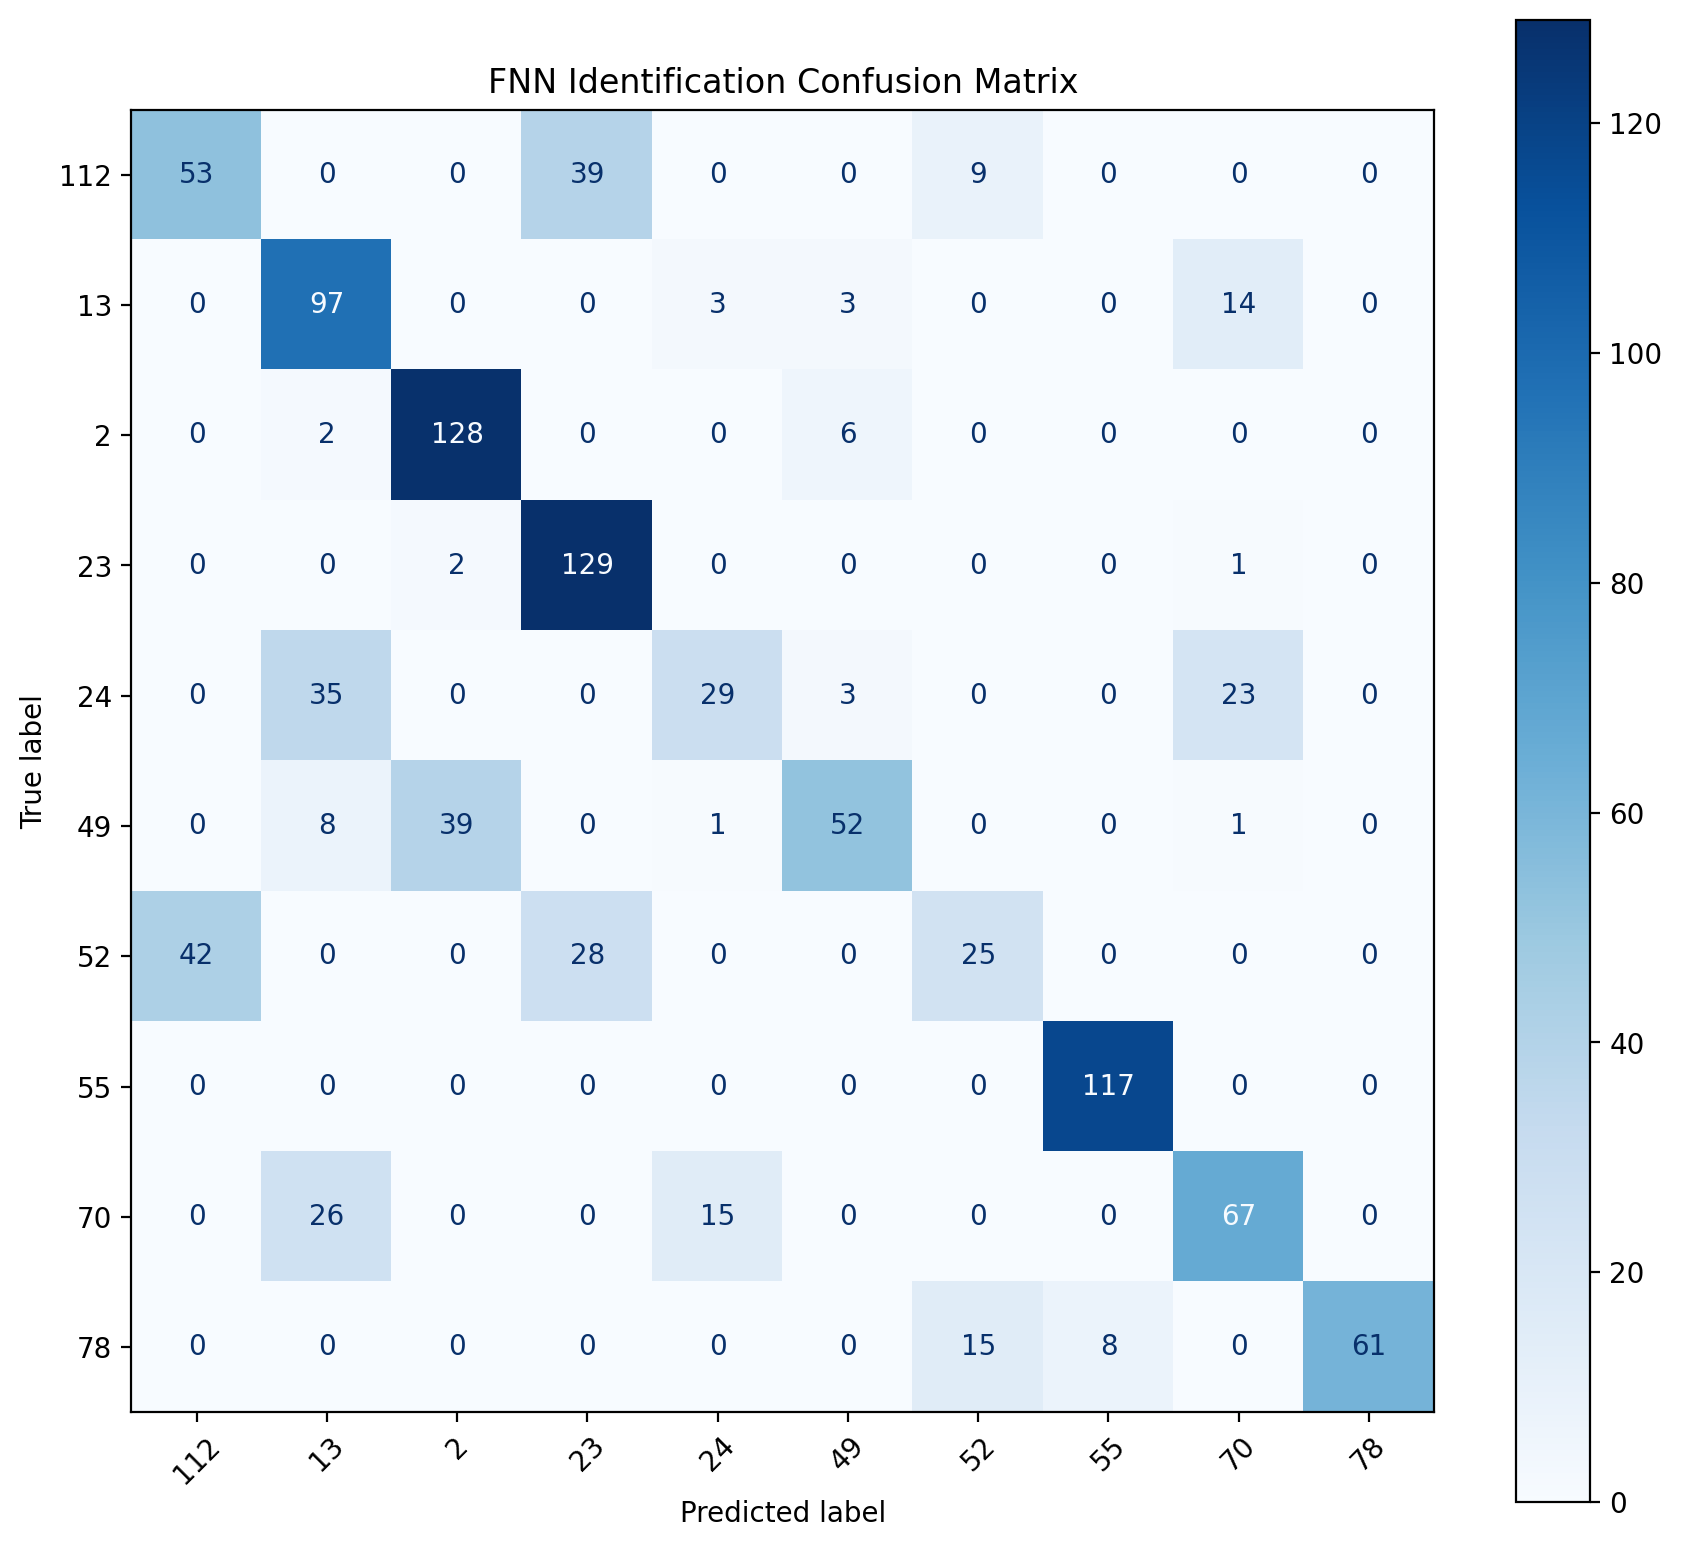


fnn_identification_training_curves.png


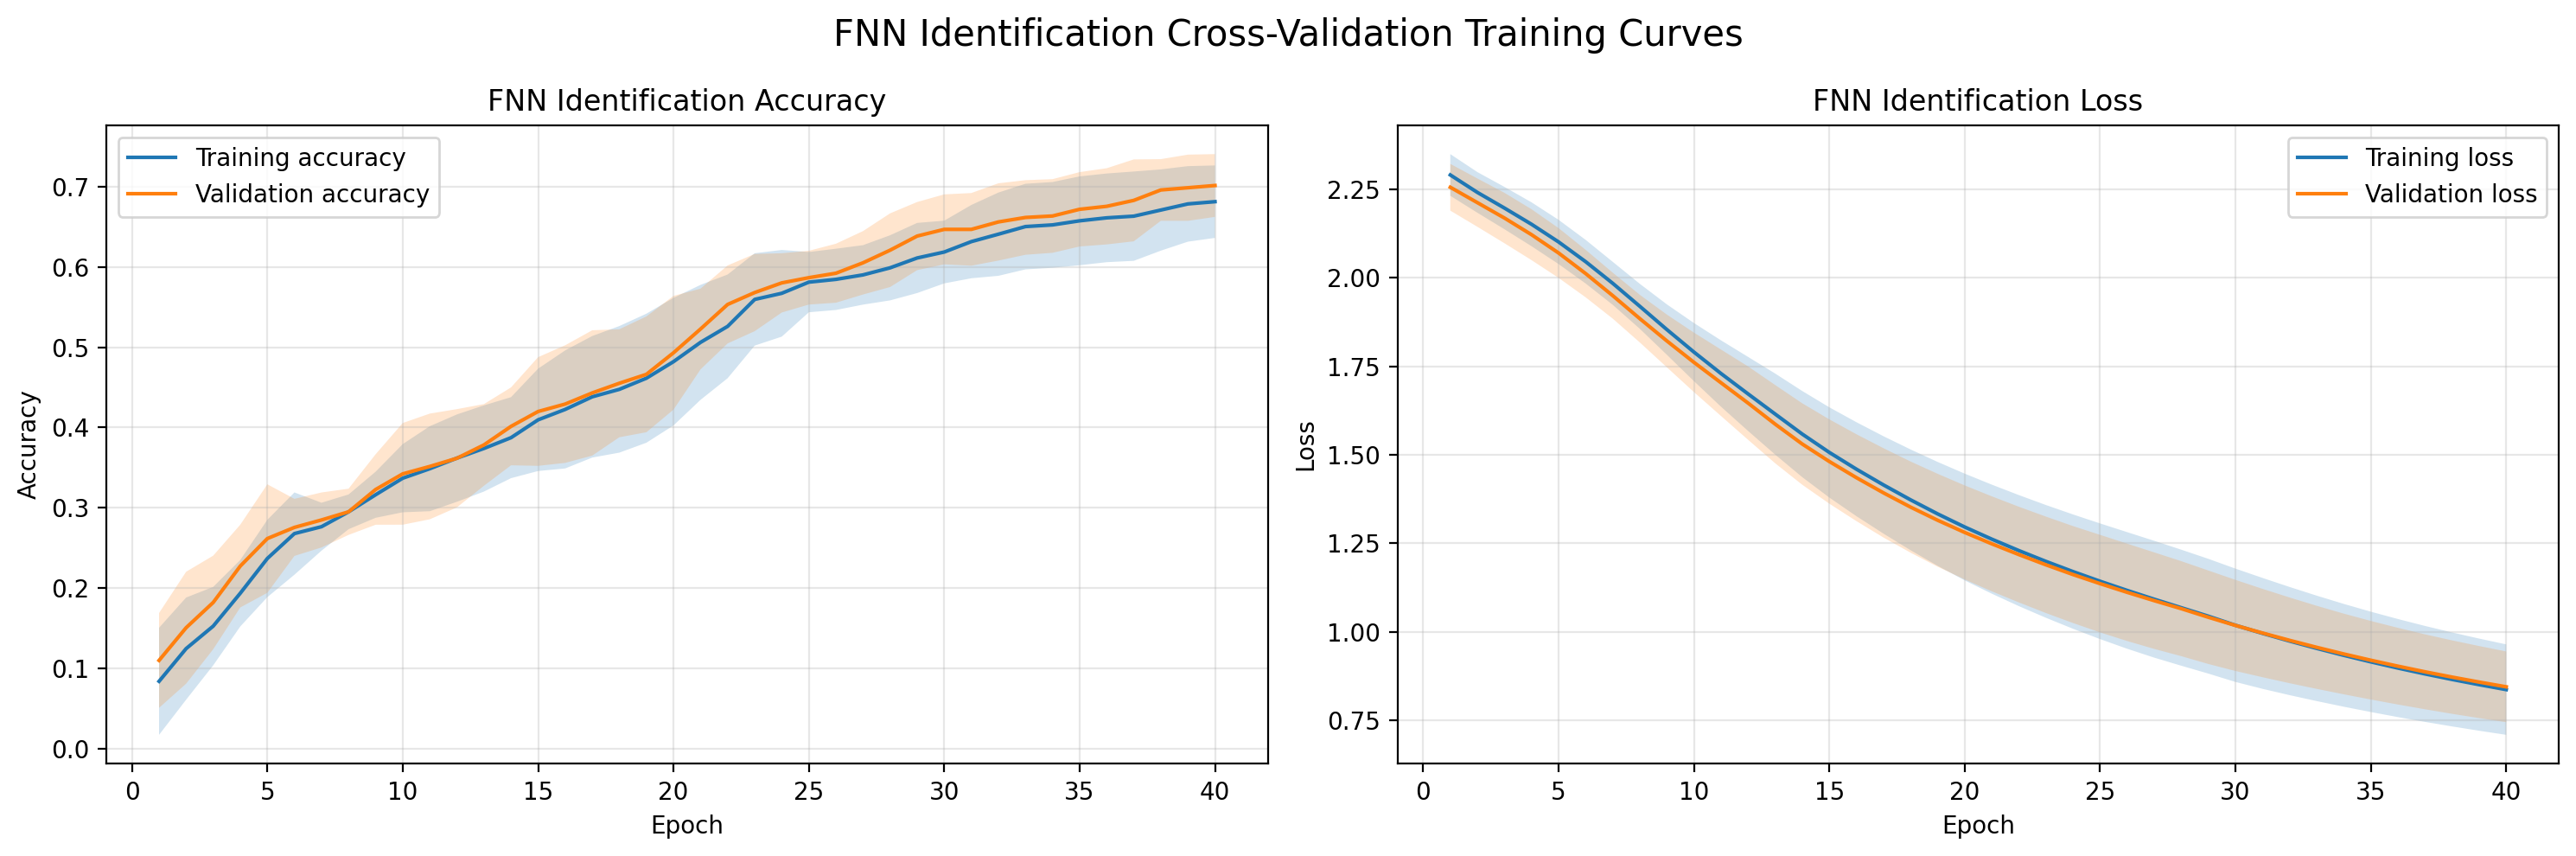


fnn_verification_roc_user_55.png


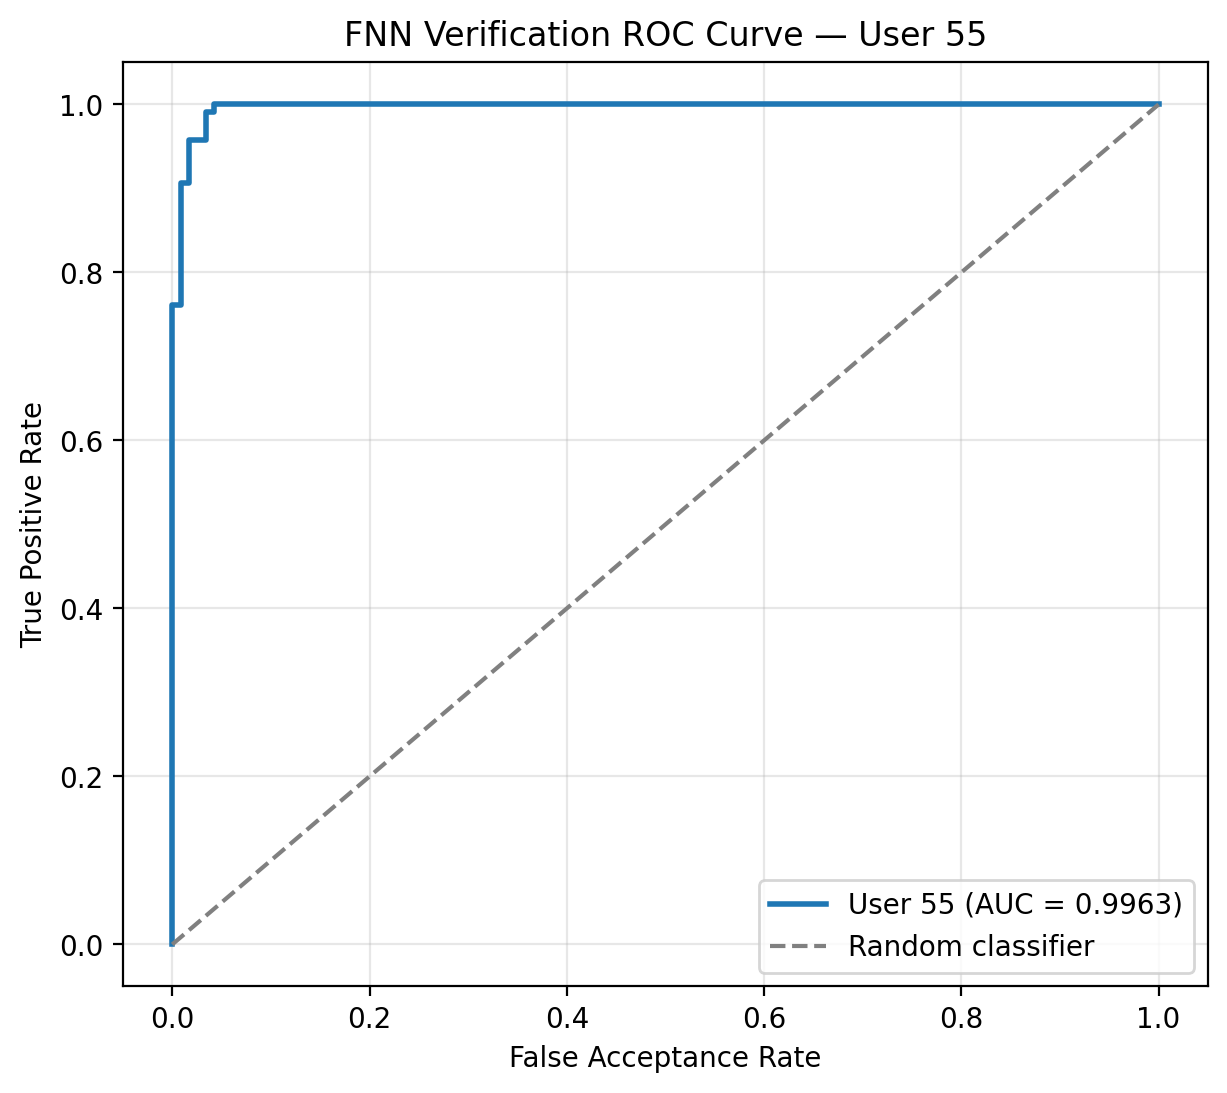


lstm_identification_confusion_matrix.png


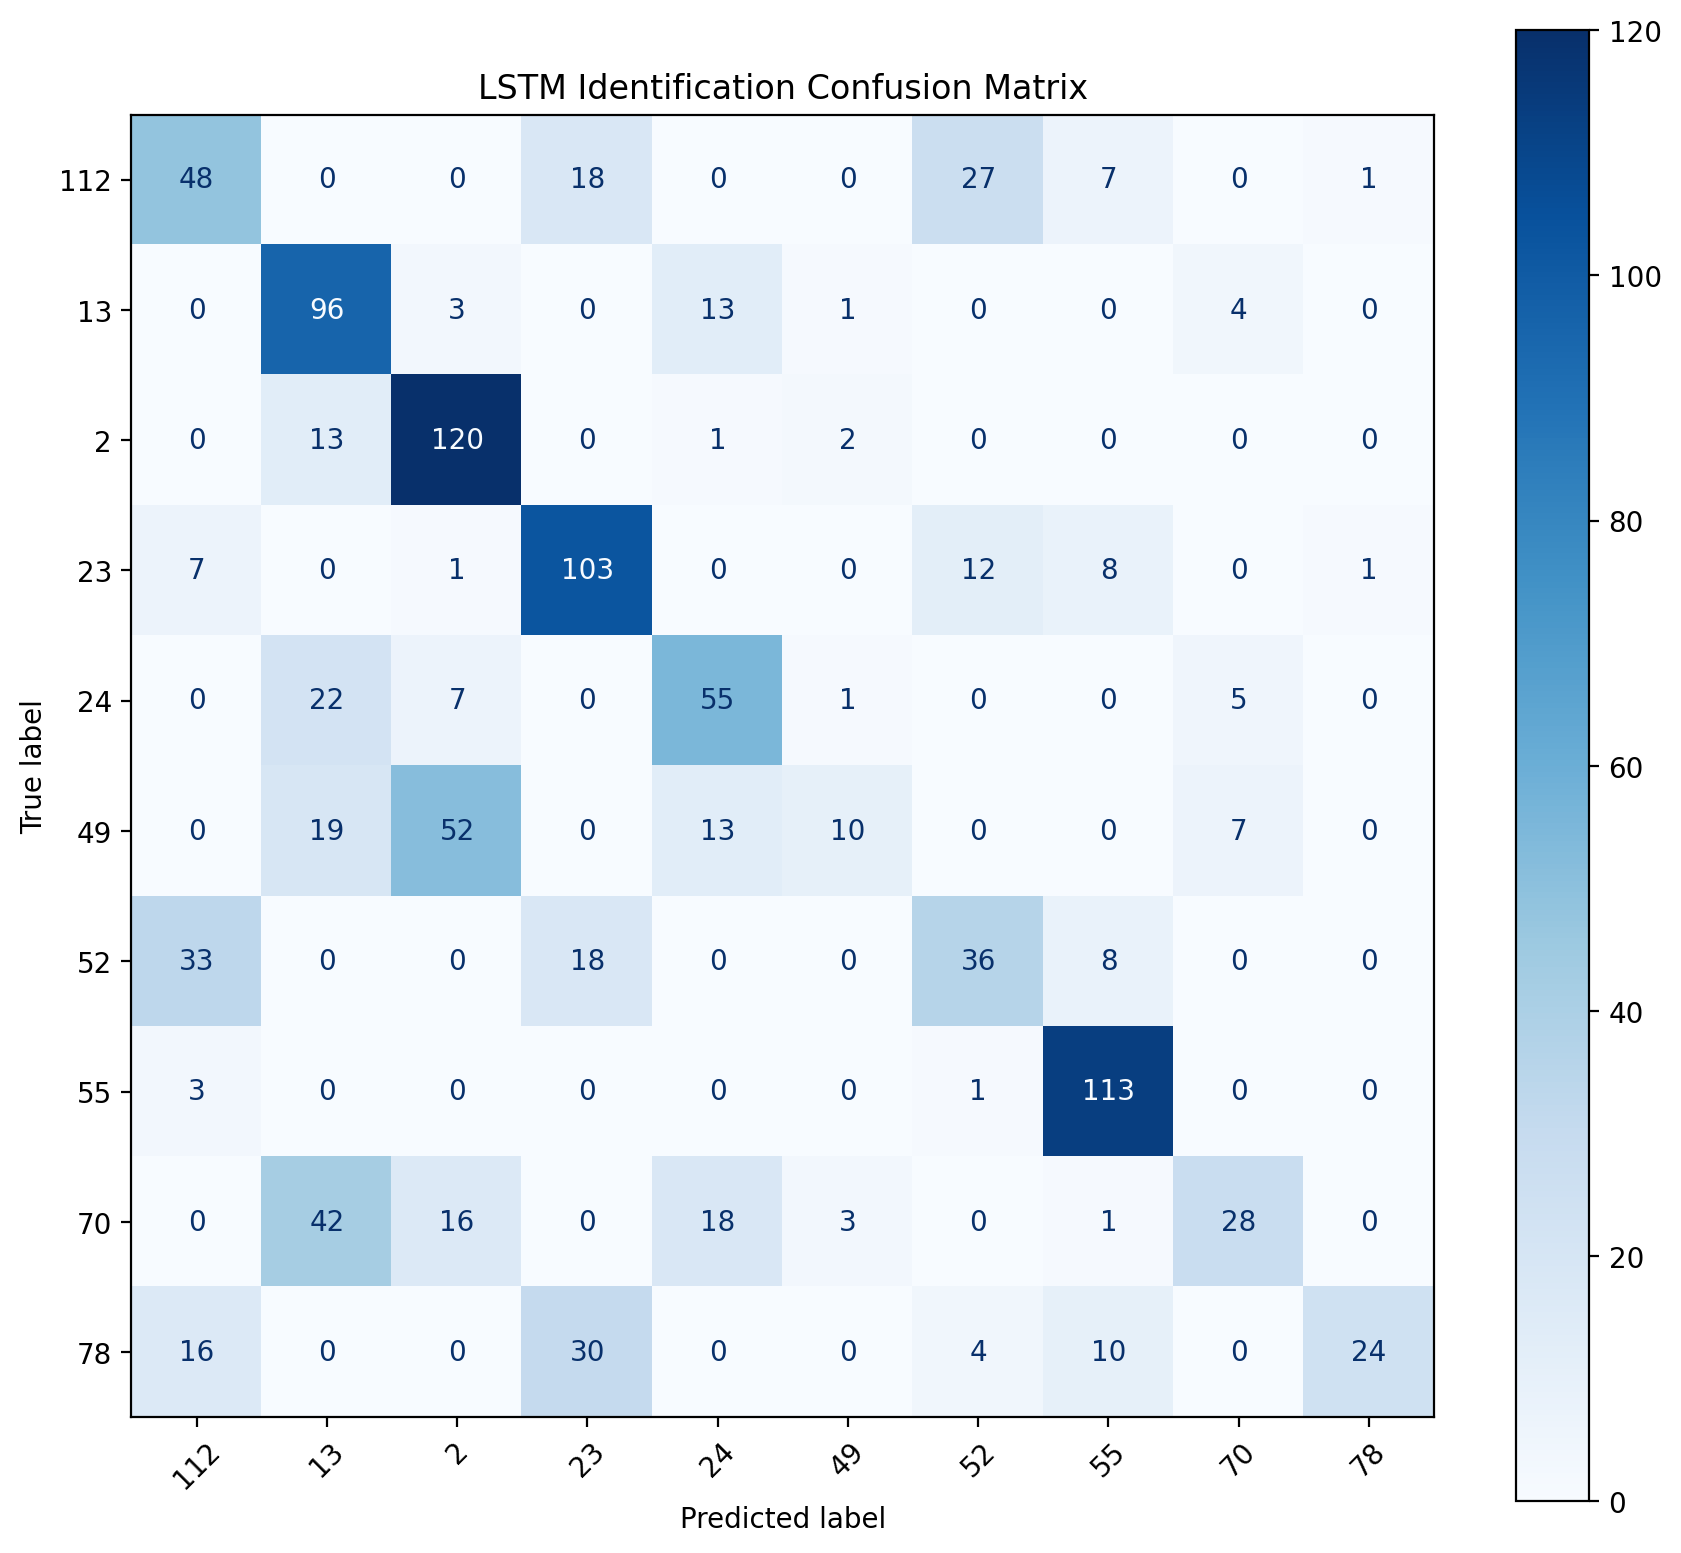


lstm_identification_training_curves.png


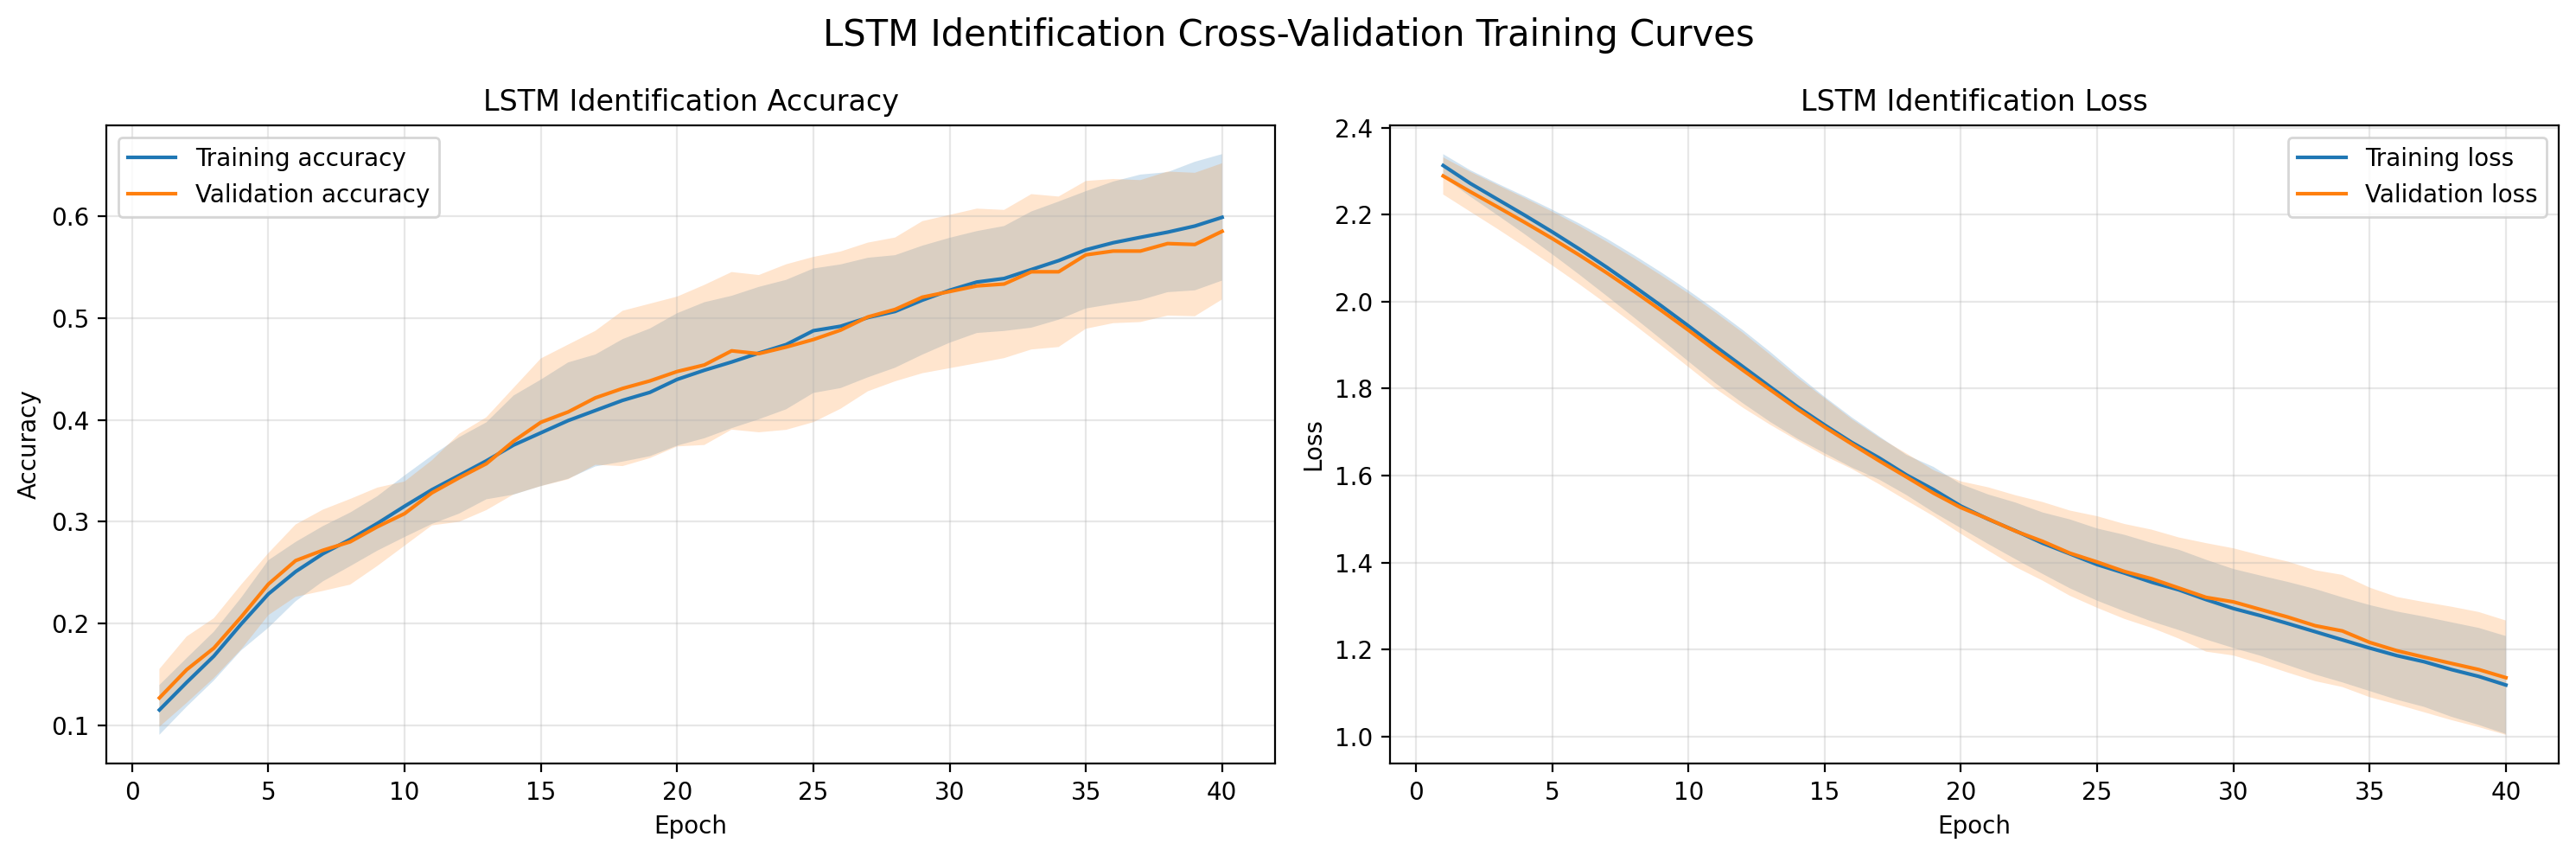


lstm_verification_roc_user_55.png


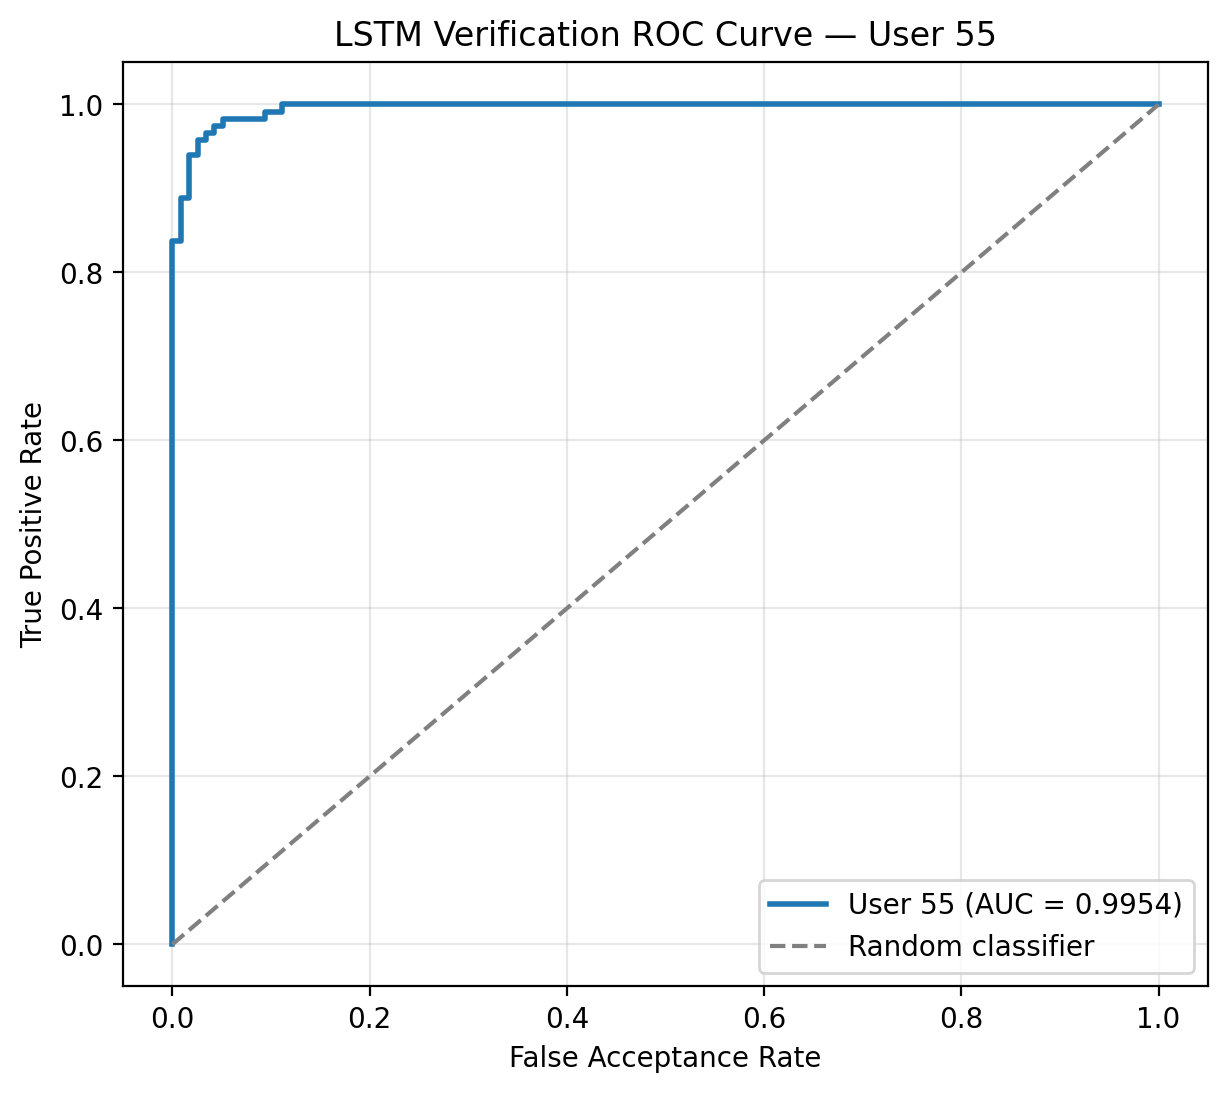

In [3]:
# Display all saved plots
from pathlib import Path
from IPython.display import display, Image

PLOTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/plots"
)

plot_files = sorted(PLOTS_DIR.glob("*.png"))

print(f"Saved plot files: {len(plot_files)}")
for plot_file in plot_files:
    print(plot_file.name)

print("\nDisplaying saved plots:\n")

for plot_file in plot_files:
    print(f"\n{plot_file.name}")
    display(Image(filename=str(plot_file)))

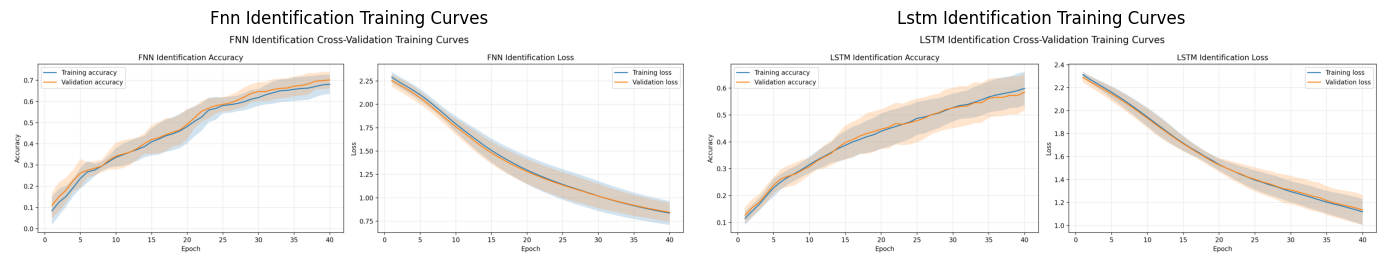

Saved: /content/drive/MyDrive/processed_data/plots/identification_training_curves_comparison.png


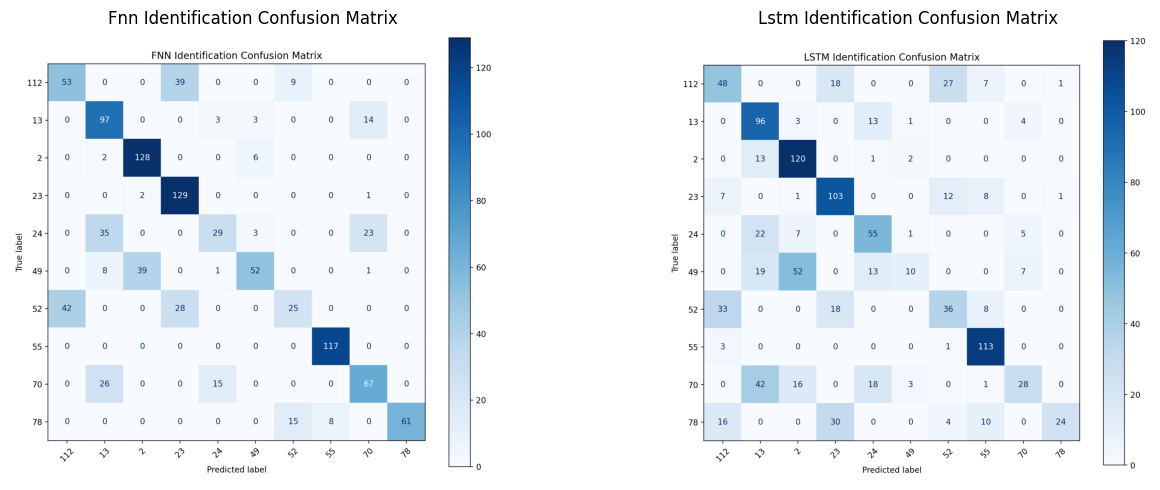

Saved: /content/drive/MyDrive/processed_data/plots/identification_confusion_matrices_comparison.png


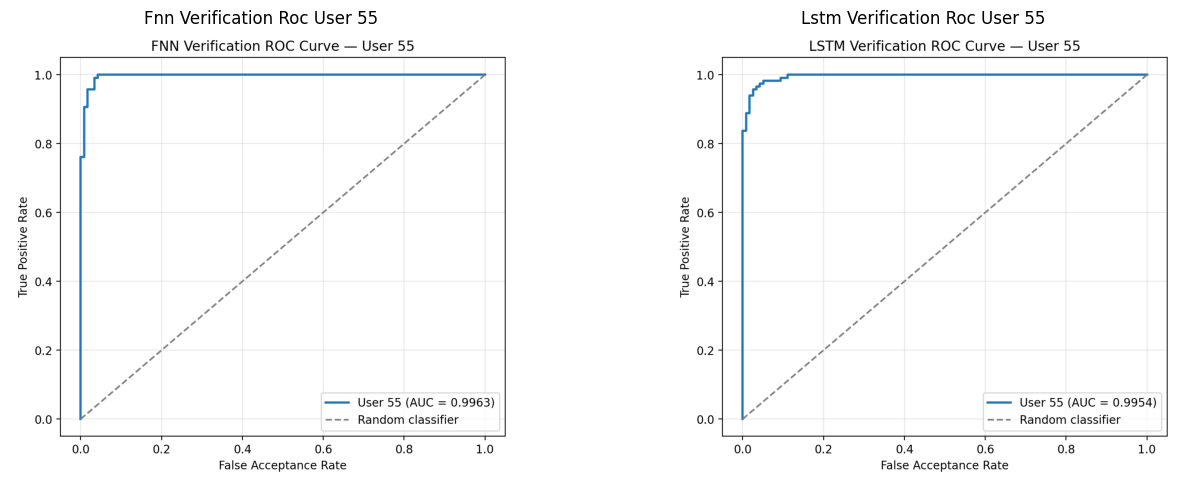

Saved: /content/drive/MyDrive/processed_data/plots/verification_roc_curves_comparison.png


In [5]:
# Combine paired plots
import matplotlib.pyplot as plt
from PIL import Image

plot_groups = {
    "identification_training_curves_comparison.png": [
        "fnn_identification_training_curves.png",
        "lstm_identification_training_curves.png"
    ],
    "identification_confusion_matrices_comparison.png": [
        "fnn_identification_confusion_matrix.png",
        "lstm_identification_confusion_matrix.png"
    ],
    "verification_roc_curves_comparison.png": [
        "fnn_verification_roc_user_55.png",
        "lstm_verification_roc_user_55.png"
    ]
}

for output_name, filenames in plot_groups.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, filename in zip(axes, filenames):
        image = Image.open(PLOTS_DIR / filename)
        ax.imshow(image)
        ax.set_title(filename.replace(".png", "").replace("_", " ").title())
        ax.axis("off")

    plt.tight_layout()
    output_path = PLOTS_DIR / output_name
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {output_path}")